<!--
  SPDX-FileCopyrightText: 2026 Advanced Micro Devices, Inc.
  SPDX-License-Identifier: Apache-2.0
-->

# Running ComfyUI generative workflows from Python on AMD Instinct™ GPUs

**Knowledge level**: Intermediate — comfortable with Python and the Linux command line; no prior ComfyUI experience required.

**Content category**: Inference

## Introduction

**The goal of this tutorial is to teach you how to drive [ComfyUI](https://www.comfy.org/) generative-AI workflows entirely from Python — with no browser — on AMD Instinct™ data-center GPUs running the [ROCm™](https://rocm.docs.amd.com/) software stack.** ComfyUI ships an HTTP API, so instead of clicking around a graphical editor you launch the server, submit a workflow as a JSON document, wait for it to finish, and pull the results back into your notebook. This headless, scriptable approach is what you need on a remote server with no display, and it is the basis for automating generative pipelines in scripts, CI, or batch jobs on HPC and cloud infrastructure.

To keep the example concrete, we run two real workflows on the same three input photographs: **Hunyuan3D v2.1** (turns a photo into a 3D mesh) and **Wan2.2 5B** (turns a photo into a short video). You submit both from Python and display their outputs inline.

If some of these terms are new to you, don't worry — the next section ("Key concepts") explains each one in plain language before you run any code.

> **Companion tutorial:** This notebook is a follow-up to [*Text-to-video generation with ComfyUI and an AMD Radeon™ GPU*](https://rocm.docs.amd.com/projects/ai-developer-hub/en/latest/notebooks/inference/t2v_comfyui_radeon.html). If you are brand new to ComfyUI, start there: it walks through the **interactive browser UI** on a single **consumer Radeon GPU**. This tutorial picks up where that one leaves off (see "How this tutorial differs" below).

> **Companion blog post:** For background on ComfyUI performance work on AMD Instinct GPUs, see the AMD ROCm blog [*Accelerating ComfyUI Workflows on AMD Instinct MI355X GPUs with ROCm*](https://rocm.blogs.amd.com/artificial-intelligence/comfyui/README.html).

### What you will learn

The **core skills** — driving ComfyUI programmatically on AMD Instinct:

- How to launch the ComfyUI server and confirm a ROCm + PyTorch runtime (**Part 1**).
- How ComfyUI's HTTP API works, and how a few small helpers submit a workflow, poll for completion, and retrieve outputs (**Part 1**).
- How to run two real diffusion workflows from Python and display their outputs (**Part 2**):
  - **[Hunyuan3D v2.1](https://huggingface.co/tencent/Hunyuan3D-2.1)** — *image-to-3D*: a single photo becomes a 3D mesh (`.glb`).
  - **[Wan2.2 5B image-to-video](https://huggingface.co/Comfy-Org/Wan_2.2_ComfyUI_Repackaged)** — *image-to-video*: a single photo becomes a short MP4 camera orbit.

The **optional step**:

- How to wrap a workflow in a small harness and measure throughput **on your own hardware** (**Part 3**).

### Workflow at a glance

1. **Set up** — launch the ComfyUI server inside a ROCm container and load the API helpers (Part 1).
2. **Generate** — run the Hunyuan3D and Wan2.2 workflows on three photos and visualize the results (Part 2).
3. **Measure** *(optional)* — benchmark a workflow on your own GPU (Part 3).

### How this tutorial differs from the Radeon ComfyUI tutorial

Both tutorials use ComfyUI on AMD GPUs, but they target different audiences and workflows:

| | Radeon tutorial (prerequisite) | This tutorial |
|---|---|---|
| **Hardware** | Consumer **AMD Radeon™** GPU (e.g. RX 7900 XTX) | Data-center **AMD Instinct™** GPUs (MI300X / MI325X / MI350X / MI355X) |
| **How you drive ComfyUI** | Interactively, in the **browser UI** | **Headless, from Python** over the HTTP API (no browser) |
| **Workflows shown** | A single text-to-video workflow | **Two** workflows: image-to-3D and image-to-video |
| **Best for** | Learning ComfyUI hands-on at your desk | **Automating** generative workflows on remote servers and in pipelines |

In short: the Radeon tutorial teaches you ComfyUI interactively; this one shows you how to **operate it as a service** on server-class hardware.

## Key concepts

This section introduces the main pieces of technology used in this tutorial. Skim it once now; you can refer back to it whenever a term comes up later.

### Diffusion models

**Diffusion models** are the generative-AI models behind most modern image, video, and 3D generation. They learn to start from random noise and iteratively "denoise" it into a coherent result, guided by your prompt or input image. Each iteration is called a *step*.

### ComfyUI and workflows

**[ComfyUI](https://www.comfy.org/)** is an open-source, **node-based** interface for diffusion models. You build a pipeline by wiring together nodes — "load a model", "encode a prompt", "sample", "decode", "save" — into a graph called a **workflow**. ComfyUI can export any workflow to a JSON document ("API format"); this tutorial submits those JSON workflows directly, so we never need the visual editor.

### Driving ComfyUI headlessly (the HTTP API)

ComfyUI runs as a long-lived **HTTP server**. Besides the browser UI, it exposes an API: you `POST` a workflow to `/prompt`, poll `/history/<id>` until it finishes, and download generated files from `/view`. "Headless" means using only this API, with no display attached — the standard way to run on a remote data-center node.

### The two workflows

- **[Hunyuan3D v2.1](https://huggingface.co/tencent/Hunyuan3D-2.1)** is an *image-to-3D* model: from one photo it produces a 3D mesh saved as a `.glb` file.
- **[Wan2.2 5B](https://huggingface.co/Comfy-Org/Wan_2.2_ComfyUI_Repackaged)** is an *image-to-video* model: from one photo (plus a text prompt) it synthesizes a short video where every frame is generated.

### ROCm and AMD Instinct GPUs

**[ROCm™](https://rocm.docs.amd.com/)** is AMD's open software platform for GPU computing — the AMD counterpart to CUDA. **AMD Instinct™** GPUs (MI300X, MI325X, MI350X, MI355X) are AMD's data-center accelerators for AI. We run everything inside a ROCm **Docker container** so the environment is reproducible.

## Prerequisites

### Hardware

- An AMD Instinct™ GPU: **MI300X**, **MI325X**, **MI350X**, or **MI355X**, with enough VRAM to load the model checkpoints used below.

### Software

The table below lists the **exact versions this tutorial was tested against**. Other versions may work but have not been validated, so we recommend matching these.

| Component | Version (tested) | Reference |
|---|---|---|
| ROCm | 7.2.0 | [Quick-start install guide](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html) |
| Docker | 24.0.7 | [Docker install guide](https://docs.docker.com/get-docker/) |
| `rocm/comfyui` image | `comfyui-0.18.2.amd0_rocm7.2.0_ubuntu24.04` | ComfyUI-on-ROCm image (pulled in Environment setup) |
| PyTorch | 2.10 (ROCm 7.2 build) | Ships inside the image |

You do **not** need to build anything by hand — the container image ships ComfyUI and a ROCm-enabled PyTorch. The model checkpoints (~27 GB total) are **not** bundled; Part 2 can download them from Hugging Face for you when you opt in by setting `DOWNLOAD_MODELS = True` (see the configuration cell in Part 1). Make sure you have enough free disk space before enabling it.

> **Tip:** Confirm Docker is installed and that your user can run it without `sudo` by running `docker run hello-world` in a terminal before you start.

## Environment setup

This section gets you from "a machine with AMD Instinct GPUs" to "this notebook open and running inside a ComfyUI-on-ROCm container." It is aimed at readers who are new to AMD GPUs, Docker, or JupyterLab — if you are already set up, feel free to skim it.

All workflows in this notebook run **inside** the container, where the `COMFYUI_PATH` environment variable points at the ComfyUI source tree (typically `/workload/ComfyUI`).

### 1. Pull the image and launch the container

Pull the pre-built ComfyUI-on-ROCm image and start a container with the AMD GPUs exposed. We forward two ports to the host — **8888** for JupyterLab (next step) and **8188** for the ComfyUI server (started in Part 1) — and mount the directory that contains this repository so the notebook and its assets are visible inside the container.

```bash
docker pull rocm/comfyui:comfyui-0.18.2.amd0_rocm7.2.0_ubuntu24.04

# Run from the directory where you cloned this repository.
docker run -it --rm \
  --device=/dev/kfd \
  --device=/dev/dri \
  --group-add video \
  --cap-add=SYS_PTRACE \
  --security-opt seccomp=unconfined \
  --ipc=host \
  --shm-size=16g \
  -p 8888:8888 \
  -p 8188:8188 \
  -e COMFYUI_PATH=/workload/ComfyUI \
  -v "$PWD:/work" \
  rocm/comfyui:comfyui-0.18.2.amd0_rocm7.2.0_ubuntu24.04
```

This drops you into a shell **inside** the container, with this repository available under `/work`. Run the remaining steps there.

### 2. Open this notebook in JupyterLab

The image does not start JupyterLab automatically. From the container shell, install it (once) and start it bound to all interfaces so Docker's port forwarding can reach it:

```bash
pip install jupyterlab
jupyter lab --no-browser --ip=0.0.0.0 --port=8888 --allow-root --notebook-dir=/work
```

On startup it prints a URL containing a one-time token, for example `http://127.0.0.1:8888/lab?token=<long-token>`.

**If the GPU machine is remote** (you SSH into it), open a second terminal on your laptop and forward both ports so you can reach the server and the ComfyUI UI from your local browser:

```bash
ssh -L 8888:localhost:8888 -L 8188:localhost:8188 <user>@<gpu-host>
```

Paste the printed `http://127.0.0.1:8888/lab?token=...` URL into your browser, then open this notebook at `docs/notebooks/inference/t2v_comfyui_api_mode_instinct.ipynb`. To stop the server when you are done, press `Ctrl+C` twice in the container shell.

### 3. Confirm the GPUs are visible

ROCm ships `amd-smi`, a command-line tool that lists the AMD GPUs the container can see (the AMD counterpart to `nvidia-smi`). Run the cell below; you should see one or more AMD Instinct GPUs. If the command is not found or no GPU appears, recheck the container's `--device` flags and your ROCm install before continuing.

In [1]:
# List the AMD GPUs visible inside the container. You should see your Instinct GPU(s).
# For ROCm 6.4 and earlier, use `rocm-smi` instead of `amd-smi`.
!amd-smi list || rocm-smi

GPU: 0
    BDF: 0000:09:00.0
    UUID: 41ff74a5-0000-1000-802a-2af56d9fcea0
    KFD_ID: 49827
    NODE_ID: 3
    PARTITION_ID: 0

GPU: 1
    BDF: 0000:1a:00.0
    UUID: 92ff74a5-0000-1000-80b6-6ddb632f890a
    KFD_ID: 65518
    NODE_ID: 5
    PARTITION_ID: 0

GPU: 2
    BDF: 0000:6b:00.0
    UUID: bbff74a5-0000-1000-8024-35b25ca644e7
    KFD_ID: 35594
    NODE_ID: 4
    PARTITION_ID: 0

GPU: 3
    BDF: 0000:79:00.0
    UUID: 55ff74a5-0000-1000-806c-23298405fe79
    KFD_ID: 9862
    NODE_ID: 2
    PARTITION_ID: 0




## Part 1 — Set up and verify ComfyUI on Instinct

With the container running and this notebook open inside it, Part 1 establishes the runtime and the server we'll talk to for the rest of the notebook. There are three short steps:

- Verify that PyTorch sees the GPU and is built with ROCm support, and set up the notebook's working directories.
- Stage the input photos and workflow files this tutorial needs.
- Launch the ComfyUI server as a background process and load a small set of HTTP API helpers reused in Parts 2 and 3.

### Install the notebook's Python dependencies

The ComfyUI-on-ROCm image ships ComfyUI and a ROCm-enabled PyTorch, but a few small **pure-Python** packages this notebook uses for *visualizing* results are not included. The cell below installs them into the running kernel:

- `trimesh` + `fast-simplification` — load and decimate the Hunyuan3D `.glb` mesh for the turntable preview (Part 2).
- `imageio` + `imageio-ffmpeg` — encode that preview to an MP4 (bundles its own `ffmpeg`, so nothing system-level is required).
- `pillow` — image handling for the inline result grid.

None of these touch the GPU; they only render the outputs for display. Run this once per fresh container.

In [2]:
%pip install --quiet trimesh fast-simplification "imageio[ffmpeg]" pillow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Verifying the runtime: PyTorch ROCm and GPU visibility

The next cell confirms that PyTorch was built with ROCm support, prints the detected device name, and locates `$COMFYUI_PATH`. Run it before the workflow sections; if it fails, fix the install before proceeding.

In [3]:
import os
import sys
import json
import shutil
import time
from copy import deepcopy
from pathlib import Path

import torch

assert torch.cuda.is_available(), (
    "No HIP / CUDA device visible to PyTorch. Check container --device flags and ROCm install."
)
print("python:", sys.version.split()[0])
print("torch: ", torch.__version__, "| HIP:", getattr(torch.version, "hip", None) or "(not a ROCm build)")
print("GPU 0: ", torch.cuda.get_device_name(0))

COMFYUI_PATH = Path(os.environ.get("COMFYUI_PATH", "/workload/ComfyUI"))
assert (COMFYUI_PATH / "main.py").is_file(), (
    f"{COMFYUI_PATH}/main.py not found - set COMFYUI_PATH to your ComfyUI checkout."
)

NOTEBOOK_DIR = Path(os.getcwd()).resolve()  # also where utils_comfyui.py lives
WORKFLOWS_DIR = NOTEBOOK_DIR / "workflows"
ASSETS_DIR = NOTEBOOK_DIR / "assets"
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

# Set to True to let Part 2 download the model checkpoints (~27 GB total) from
# Hugging Face into ComfyUI/models/. Left False by default so a first read does
# not trigger a large download; flip it once you are ready to run the workflows.
DOWNLOAD_MODELS = False

print("COMFYUI_PATH:", COMFYUI_PATH)
print("Notebook dir:", NOTEBOOK_DIR)
print("DOWNLOAD_MODELS:", DOWNLOAD_MODELS)

python: 3.12.3
torch:  2.10.0a0+git449b176 | HIP: 7.2.26015
GPU 0:  AMD Instinct MI325X
COMFYUI_PATH: /workload/ComfyUI
Notebook dir: /workload/ComfyUI/examples
DOWNLOAD_MODELS: False


### Stage the tutorial inputs and workflows

Part 2 needs two kinds of small files that are versioned with this tutorial:

- **Input photographs** — three 768x768 PNGs (`apple`, `banana`, `pineapple`).
- **Workflow definitions** — the ComfyUI API-format JSON for each of the two workflows.

These files — together with the `utils_comfyui.py` helper module — are versioned in the [ROCm/ComfyUI](https://github.com/ROCm/ComfyUI/tree/master/examples) repository under `examples/`, not in this docs repository. The next cell downloads the helper module next to this notebook (if missing) and stages the assets and workflows under the notebook's `assets/` and `workflows/` directories. If you are running inside a ComfyUI checkout that already ships these files, it finds them locally; otherwise it downloads them from `RAW_BASE_URL`.

The photographs are sourced from Wikimedia Commons; see the [input photographs README](https://github.com/ROCm/ComfyUI/blob/master/examples/assets/README.md) for the per-image licences and attribution (the apple and banana images are licensed CC BY / CC BY-SA and require attribution).

In [4]:
import urllib.request

# This tutorial's helper module and supporting files (the workflow JSONs and
# input photos) are versioned in the ROCm/ComfyUI repo under examples/, not in
# this docs repo. RAW_BASE_URL points there; the helper module is fetched next
# to this notebook if it is not already present (a no-op inside a checkout that
# already ships it).
RAW_BASE_URL = "https://raw.githubusercontent.com/ROCm/ComfyUI/master/examples"

if not (NOTEBOOK_DIR / "utils_comfyui.py").is_file():
    print("Fetching utils_comfyui.py from ROCm/ComfyUI ...")
    urllib.request.urlretrieve(f"{RAW_BASE_URL}/utils_comfyui.py",
                               str(NOTEBOOK_DIR / "utils_comfyui.py"))

from utils_comfyui import stage_files

ASSET_FILES = [
    "amd_comfyui_tutorial_apple_seed.png",
    "amd_comfyui_tutorial_banana_seed.png",
    "amd_comfyui_tutorial_pineapple_seed.png",
]
WORKFLOW_FILES = [
    "hunyuan3d_v2_1_image_to_3d.json",
    "wan2_2_5b_image_to_video.json",
]

print("Input photographs:")
stage_files(ASSET_FILES, ASSETS_DIR,
            [NOTEBOOK_DIR / "assets"], f"{RAW_BASE_URL}/assets")
print("Workflow definitions:")
stage_files(WORKFLOW_FILES, WORKFLOWS_DIR,
            [NOTEBOOK_DIR / "workflows"], f"{RAW_BASE_URL}/workflows")

missing = [f for f in ASSET_FILES if not (ASSETS_DIR / f).is_file()]
missing += [f for f in WORKFLOW_FILES if not (WORKFLOWS_DIR / f).is_file()]
assert not missing, f"Could not stage {missing}. Set RAW_BASE_URL or place the files manually."
print("All inputs and workflows are in place.")

Input photographs:
  present:  amd_comfyui_tutorial_apple_seed.png
  present:  amd_comfyui_tutorial_banana_seed.png
  present:  amd_comfyui_tutorial_pineapple_seed.png
Workflow definitions:
  present:  hunyuan3d_v2_1_image_to_3d.json
  present:  wan2_2_5b_image_to_video.json
All inputs and workflows are in place.


### Launching the ComfyUI server in the background

ComfyUI runs as a long-lived HTTP server. The next cell starts `python $COMFYUI_PATH/main.py --listen --port 8188` in the background, captures its PID, and waits for the `/system_stats` endpoint to return 200 (which signals "ready to accept prompts"). If a server is already running on `127.0.0.1:8188` (for example you started it manually before opening Jupyter), the cell detects that and becomes a no-op.

The PID is stored in `server_pid`; the final cell of the notebook will terminate it.

In [5]:
from utils_comfyui import start_comfyui_server

SERVER_PORT = int(os.environ.get("COMFYUI_PORT_HOST", "8188"))
SERVER_URL = f"http://127.0.0.1:{SERVER_PORT}"

server_pid = start_comfyui_server(
    COMFYUI_PATH, SERVER_URL, SERVER_PORT, OUTPUTS_DIR / "comfyui_server.log"
)

Starting ComfyUI server -> http://127.0.0.1:8188 (log: /workload/ComfyUI/examples/outputs/comfyui_server.log)


Server ready (pid=198).


### The ComfyUI HTTP API and a tiny client

We drive the server through three endpoints:

- `POST /prompt` — submit a workflow (returns a `prompt_id`).
- `GET /history/<prompt_id>` — check whether a run has finished.
- `GET /view` — download a generated file.

To keep this notebook readable, the small client that wraps these calls lives in the companion module [`utils_comfyui.py`](https://github.com/ROCm/ComfyUI/blob/master/examples/utils_comfyui.py), staged next to this notebook by the cell above. Its `ComfyUIClient` exposes `queue_prompt`, `wait_for_completion`, and `download_outputs`, plus a `run_workflow` convenience method that chains all three (submit → wait → download). The full API is documented in the [ComfyUI server docs](https://docs.comfy.org/development/comfyui-server/comms_overview).

In [6]:
from utils_comfyui import ComfyUIClient

client = ComfyUIClient(SERVER_URL)
print("ComfyUI client ready ->", client.server_url)

ComfyUI client ready -> http://127.0.0.1:8188


## Part 2 - Two diffusion workflows on real photographs

Part 2 demonstrates two **independent** ComfyUI generative workflows, both driven from Python over the HTTP API we set up in Part 1, on the same set of input photographs (apple, banana, pineapple, 768x768 each). The two workflows do not share state - both consume the input photo; neither output feeds the other.

| | Workflow | Input | AI output |
|---|---|---|---|
| Example A | **[Hunyuan3D v2.1](https://huggingface.co/tencent/Hunyuan3D-2.1)** - flow-based diffusion transformer for image-to-3D, `octree_resolution=4096` | one photograph | a watertight 3D mesh in glTF (`.glb`) format - the geometry is the AI output |
| Example B | **[Wan2.2 5B image-to-video](https://huggingface.co/Comfy-Org/Wan_2.2_ComfyUI_Repackaged)** (TI2V variant) - 5B-parameter video diffusion transformer | the same photograph plus a text prompt | an MP4 clip (81 frames at 24 fps) where every frame is generated by the model |

The visualisation cell at the end of Part 2 lays out a 3-row grid:

- **Row 1 (input photo):** the source photograph fed to both workflows.
- **Row 2 (mesh turntable):** a deterministic CPU rendering of the Hunyuan3D `.glb`. This row is *not* AI: it's a fixed-camera orthographic walk-around of the mesh that the AI produced. It tells you what the image-to-3D model *thinks* the subject's shape is, which is hard to inspect any other way without a 3D viewer.
- **Row 3 (AI camera orbit):** the Wan2.2 5B image-to-video output. This row *is* AI: every frame is generated.

Photo credits and licences for the inputs are in the [input photographs README](https://github.com/ROCm/ComfyUI/blob/master/examples/assets/README.md).


### Example A: Hunyuan3D v2.1 — image-to-3D

Our first workflow turns each photograph into a 3D mesh. The cell below stages the three input images into ComfyUI's `input/` directory, makes sure the Hunyuan3D checkpoint (~10 GB) is available, and loads the workflow JSON staged earlier.

If you set `DOWNLOAD_MODELS = True` in the configuration cell above, the checkpoint is downloaded from Hugging Face into `ComfyUI/models/checkpoints/` automatically (and skipped if already present). With the default `DOWNLOAD_MODELS = False`, the cell instead reports the checkpoint as missing and the generation step is skipped — flip the flag, or place the file there manually, when you are ready to run the workflow.

In [7]:
from utils_comfyui import download_models

# Three real-world subjects. Photo credits/licences: examples/assets/README.md in ROCm/ComfyUI.
INPUTS = [
    ("apple",     ASSETS_DIR / "amd_comfyui_tutorial_apple_seed.png"),
    ("banana",    ASSETS_DIR / "amd_comfyui_tutorial_banana_seed.png"),
    ("pineapple", ASSETS_DIR / "amd_comfyui_tutorial_pineapple_seed.png"),
]

# Stage the photos where ComfyUI's LoadImage node looks for them.
COMFYUI_INPUT_DIR = COMFYUI_PATH / "input"
COMFYUI_INPUT_DIR.mkdir(exist_ok=True)
for _, asset in INPUTS:
    shutil.copy2(asset, COMFYUI_INPUT_DIR / asset.name)

# Checkpoint -> Hugging Face URL. Downloaded only when DOWNLOAD_MODELS is True.
HUNYUAN_CKPT = COMFYUI_PATH / "models" / "checkpoints" / "hunyuan_3d_v2.1.safetensors"
HUNYUAN_MODELS = {
    HUNYUAN_CKPT: "https://huggingface.co/Comfy-Org/hunyuan3D_2.1_repackaged/"
                  "resolve/main/hunyuan_3d_v2.1.safetensors",
}
HUNYUAN_READY = not download_models(HUNYUAN_MODELS, DOWNLOAD_MODELS)

with (WORKFLOWS_DIR / "hunyuan3d_v2_1_image_to_3d.json").open() as f:
    hunyuan_workflow = json.load(f)
print(f"Staged {len(INPUTS)} photos; workflow has {len(hunyuan_workflow)} nodes; checkpoint ready: {HUNYUAN_READY}")

  present:  hunyuan_3d_v2.1.safetensors
Staged 3 photos; workflow has 10 nodes; checkpoint ready: True


### Run the workflow over each input

We run the workflow once as a warm-up (which loads ~10 GB of weights and compiles the diffusion and VAE kernels), then once per input subject. Each call swaps the `LoadImage` filename and the `SaveGLB` prefix and bumps the KSampler seed so every run is fresh rather than served from cache.

In [8]:
MESHES = {}
HUNYUAN_OUT = OUTPUTS_DIR / "hunyuan3d"


def customise_hunyuan(workflow, image_name, output_prefix):
    wf = deepcopy(workflow)
    wf["2"]["inputs"]["image"] = image_name
    wf["10"]["inputs"]["filename_prefix"] = output_prefix
    wf["7"]["inputs"]["seed"] = int(time.time() * 1_000_000) % (2**63 - 1)
    return wf


if HUNYUAN_READY:
    print("Warm-up (loads weights, compiles kernels)...")
    client.run_workflow(customise_hunyuan(hunyuan_workflow, INPUTS[0][1].name, "amd_tutorial/_warmup"),
                        HUNYUAN_OUT / "_warmup")
    for name, asset in INPUTS:
        wf = customise_hunyuan(hunyuan_workflow, asset.name, f"amd_tutorial/hunyuan3d_v2_1_{name}")
        saved, _ = client.run_workflow(wf, HUNYUAN_OUT / name)
        glbs = [p for p in saved if p.suffix.lower() == ".glb"]
        MESHES[name] = glbs[0] if glbs else None
        print(f"{name:<12} -> {MESHES[name].relative_to(NOTEBOOK_DIR) if MESHES[name] else '(no .glb)'}")
else:
    print("Skipping run; checkpoint not present.")

Warm-up (loads weights, compiles kernels)...


apple        -> outputs/hunyuan3d/apple/hunyuan3d_v2_1_apple_00010_.glb


banana       -> outputs/hunyuan3d/banana/hunyuan3d_v2_1_banana_00010_.glb


pineapple    -> outputs/hunyuan3d/pineapple/hunyuan3d_v2_1_pineapple_00010_.glb


### Visualise the AI-generated mesh: deterministic turntable render

Hunyuan3D's output is a `.glb` mesh on disk. To inspect it inline — and confirm the model built a real 3D object, not a flat sticker — we render each mesh as a short MP4 turntable.

This render is **deterministic and CPU-only** (it is *not* an AI step): it loads the mesh, decimates it, and rasterises 36 rotated frames with simple Lambert shading. The implementation lives in [`utils_comfyui.py`](https://github.com/ROCm/ComfyUI/blob/master/examples/utils_comfyui.py) as `render_mesh_turntable`; the cell below just calls it on each mesh produced above.

In [9]:
from utils_comfyui import render_mesh_turntable

TURNTABLE_OUT = OUTPUTS_DIR / "mesh_turntables"
TURNTABLE_VIDEOS = {}
for name, _ in INPUTS:
    glb = MESHES.get(name)
    if glb is None or not glb.is_file():
        print(f"{name:<12} (skip) - no mesh available")
        continue
    TURNTABLE_VIDEOS[name] = render_mesh_turntable(glb, TURNTABLE_OUT / f"{name}.mp4")
    print(f"{name:<12} -> {TURNTABLE_VIDEOS[name].relative_to(NOTEBOOK_DIR)}")

apple        -> outputs/mesh_turntables/apple.mp4


banana       -> outputs/mesh_turntables/banana.mp4


pineapple    -> outputs/mesh_turntables/pineapple.mp4


### Example B: Wan2.2 5B — image-to-video

The second workflow animates each photograph into a short video (81 frames at 24 fps) where every frame is generated by the diffusion model — a genuine AI camera orbit, not a rasterization of the Hunyuan3D mesh.

Each subject gets its own positive prompt, defined in the next cell so it is easy to read and edit before re-running. The prompts deliberately emphasise *3D camera motion, not planar rotation*: Wan2.2 5B has weak parallax priors on cutout-style photos (fruit on a pure-white background) and will default to spinning the image plane unless the prompt actively asks for a 3D arc. The negative prompt rejects the failure modes we saw during prompt engineering (multiple or peeled fruit, planar rotation, fingers in frame).

In [10]:
# Per-subject positive prompts for Wan2.2 5B I2V, keyed by INPUTS name.
# Edit these and re-run the workflow cell to experiment.
SUBJECT_PROMPTS: dict[str, str] = {
    "apple": (
        "Smooth slow 360 degree camera orbit around a single round red apple "
        "on a clean white background. The camera moves steadily and "
        "continuously around the apple in a wide 3D arc, revealing the back "
        "side of the apple. The apple itself is a single fruit and stays "
        "centred. Photorealistic studio product photography, sharp focus, "
        "soft natural lighting, shallow depth of field. No people, no hands, "
        "no text."
    ),
    "banana": (
        "Smooth slow 360 degree camera orbit around exactly one single yellow "
        "banana on a clean white background. There is only one banana - one "
        "single piece of fruit - lying on its side, stationary, intact, with "
        "the curve clearly visible. The camera arcs around the banana to "
        "reveal the back side of the curve in 3D. Photorealistic studio "
        "product photography, sharp focus, soft natural lighting."
    ),
    "pineapple": (
        "Smooth slow 360 degree camera orbit around a single tall pineapple "
        "with green crown leaves on a clean white background. The camera "
        "moves steadily and continuously around the pineapple in a wide 3D "
        "arc, revealing the back side of the pineapple body and the back of "
        "the crown leaves. The pineapple itself is a single fruit and stays "
        "centred. Photorealistic studio product photography, sharp focus, "
        "soft natural lighting. No people, no hands, no text."
    ),
}

NEGATIVE_PROMPT = (
    "multiple bananas, banana hand, banana cluster, multiple fruits, fruit "
    "cluster, duplicates, two apples, two bananas, two pineapples, sliced, "
    "peeled, cut open, chopped, broken fruit, mashed, deformed fruit, "
    "flat 2D rotation, planar rotation, sliding image, no parallax, "
    "human, person, hands, fingers, body, face, arms, lamp, text, watermark, "
    "logo, low quality, blurry, jpeg artifacts, distorted, deformed, extra "
    "limbs, motion blur, tilted, falling, flying, cartoon"
)

print(f"Defined positive prompts for {len(SUBJECT_PROMPTS)} subjects.")
print(f"Negative prompt: {len(NEGATIVE_PROMPT)} chars.")


Defined positive prompts for 3 subjects.
Negative prompt: 462 chars.


With the prompts defined, make sure the Wan2.2 checkpoints (~17 GB across the diffusion model, text encoder, and VAE) are available and prepare the per-subject workflow customizer. As in Example A, these are downloaded from Hugging Face only when `DOWNLOAD_MODELS = True`; otherwise the cell reports them as missing and the video step is skipped.

In [11]:
# Three checkpoints -> their Hugging Face URLs (Comfy-Org repackaged split files).
WAN_BASE = "https://huggingface.co/Comfy-Org/Wan_2.2_ComfyUI_Repackaged/resolve/main/split_files"
WAN_MODELS = {
    COMFYUI_PATH / "models" / "diffusion_models" / "wan2.2_ti2v_5B_fp16.safetensors":
        f"{WAN_BASE}/diffusion_models/wan2.2_ti2v_5B_fp16.safetensors",
    COMFYUI_PATH / "models" / "text_encoders" / "umt5_xxl_fp8_e4m3fn_scaled.safetensors":
        f"{WAN_BASE}/text_encoders/umt5_xxl_fp8_e4m3fn_scaled.safetensors",
    COMFYUI_PATH / "models" / "vae" / "wan2.2_vae.safetensors":
        f"{WAN_BASE}/vae/wan2.2_vae.safetensors",
}
WAN_I2V_READY = not download_models(WAN_MODELS, DOWNLOAD_MODELS)

with (WORKFLOWS_DIR / "wan2_2_5b_image_to_video.json").open() as f:
    wan_workflow = json.load(f)


def customise_wan(workflow, image_name, output_prefix, positive, negative=NEGATIVE_PROMPT):
    wf = deepcopy(workflow)
    wf["56"]["inputs"]["image"] = image_name
    wf["58"]["inputs"]["filename_prefix"] = output_prefix
    wf["3"]["inputs"]["seed"] = int(time.time() * 1_000_000) % (2**63 - 1)
    wf["6"]["inputs"]["text"] = positive
    wf["7"]["inputs"]["text"] = negative
    return wf


print(f"Loaded Wan2.2 workflow ({len(wan_workflow)} nodes); checkpoints ready: {WAN_I2V_READY}")

  present:  wan2.2_ti2v_5B_fp16.safetensors
  present:  umt5_xxl_fp8_e4m3fn_scaled.safetensors
  present:  wan2.2_vae.safetensors
Loaded Wan2.2 workflow (12 nodes); checkpoints ready: True


Now run the workflow for each subject:

In [12]:
WAN_OUT = OUTPUTS_DIR / "wan2_2_5b_i2v"
WAN_VIDEOS = {}
if WAN_I2V_READY:
    print("Warm-up (loads weights, compiles kernels)...")
    client.run_workflow(
        customise_wan(wan_workflow, INPUTS[0][1].name, "amd_tutorial/_wan_warmup", SUBJECT_PROMPTS[INPUTS[0][0]]),
        WAN_OUT / "_warmup",
    )
    for name, asset in INPUTS:
        wf = customise_wan(wan_workflow, asset.name, f"amd_tutorial/wan22_5b_i2v_{name}", SUBJECT_PROMPTS[name])
        saved, _ = client.run_workflow(wf, WAN_OUT / name)
        mp4s = [p for p in saved if p.suffix.lower() == ".mp4"]
        WAN_VIDEOS[name] = mp4s[0] if mp4s else None
        print(f"{name:<12} -> {WAN_VIDEOS[name].relative_to(NOTEBOOK_DIR) if WAN_VIDEOS[name] else '(no .mp4)'}")
else:
    print("Skipping Wan2.2 5B I2V; checkpoints not present.")

Warm-up (loads weights, compiles kernels)...


apple        -> outputs/wan2_2_5b_i2v/apple/wan22_5b_i2v_apple_00007_.mp4


banana       -> outputs/wan2_2_5b_i2v/banana/wan22_5b_i2v_banana_00007_.mp4


pineapple    -> outputs/wan2_2_5b_i2v/pineapple/wan22_5b_i2v_pineapple_00007_.mp4


### Side-by-side: input photo, AI mesh turntable, AI camera orbit

Finally, lay the results out as a grid — three rows, one column per subject:

- **Row 1 — Input photo.** The 768x768 PNG fed to both workflows.
- **Row 2 — Mesh turntable.** The deterministic CPU render of the Hunyuan3D `.glb` (the mesh is the AI output; the rotation is fixed).
- **Row 3 — AI camera orbit.** The Wan2.2 5B output, where every frame is generated by the diffusion model.

`result_grid_html` (in [`utils_comfyui.py`](https://github.com/ROCm/ComfyUI/blob/master/examples/utils_comfyui.py)) embeds each item as base64, so the rendered notebook is self-contained.


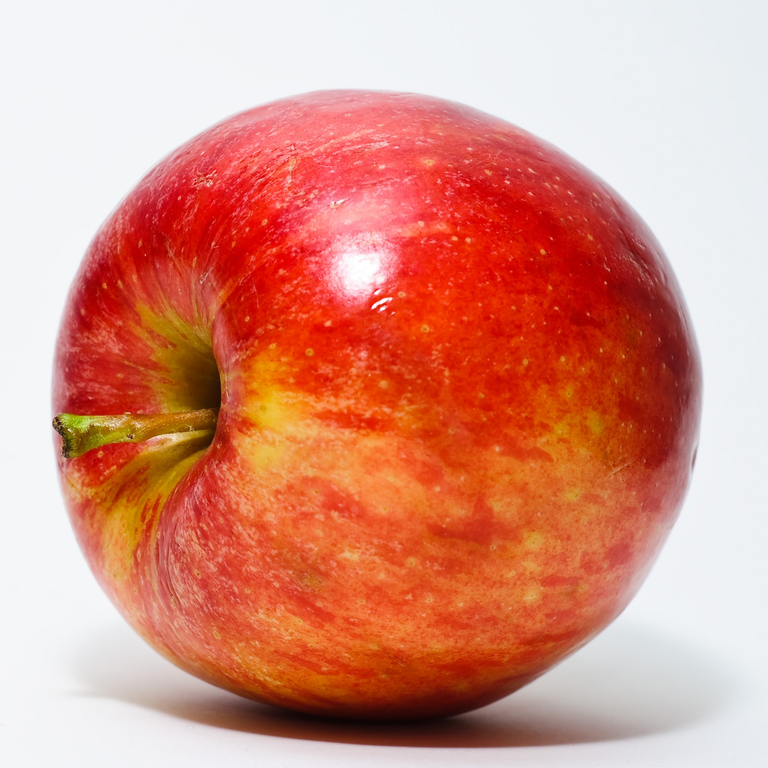
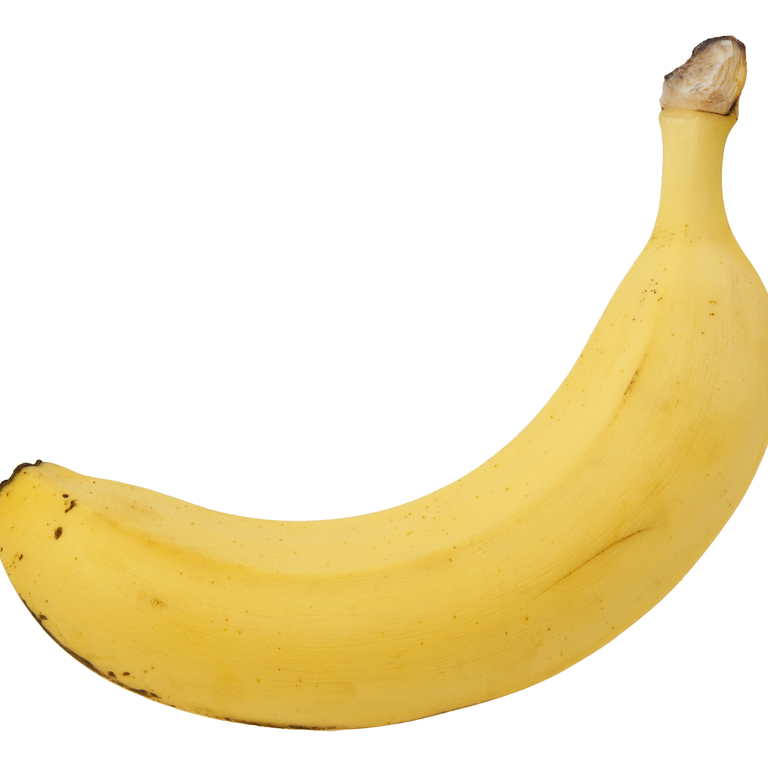
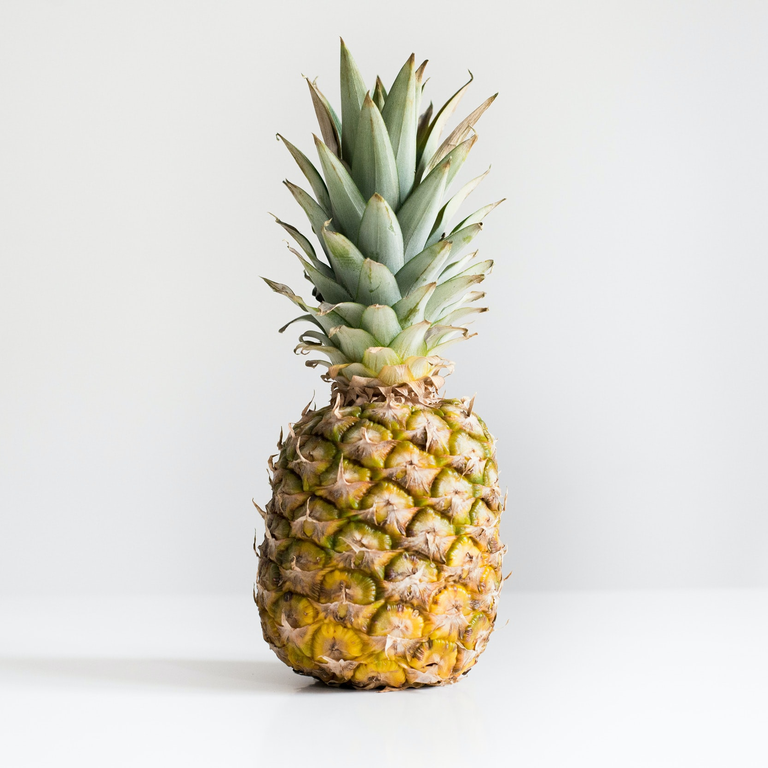

In [13]:
from utils_comfyui import result_grid_html
from IPython.display import HTML, display

display(HTML(result_grid_html(INPUTS, MESHES, TURNTABLE_VIDEOS, WAN_VIDEOS)))

## Part 3 — Measure throughput on your own hardware (optional)

This part is **opt-in**. Set `RUN_BENCHMARK = True` in the configuration cell below to run it; the default is `False` so the notebook stays a quick demo for first-time readers.

**The goal of this experiment** is to answer a practical question on *your* hardware: *how long does a given workflow take, end to end, from submitting the prompt to saving the output?* The harness runs one warm-up pass (to load weights and compile kernels) followed by several timed iterations, then reports the **mean and standard deviation of your own measurements**. The timing logic lives in `benchmark_workflow` in [`utils_comfyui.py`](https://github.com/ROCm/ComfyUI/blob/master/examples/utils_comfyui.py).

This notebook ships with **no pre-recorded numbers** — every figure below is produced by the run you trigger. If you would like to compare your results against AMD's published reference figures, see the AMD ROCm blog [*Accelerating ComfyUI Workflows on AMD Instinct MI355X GPUs with ROCm*](https://rocm.blogs.amd.com/artificial-intelligence/comfyui/README.html).

By default the harness re-runs the Hunyuan3D workflow from Part 2. To benchmark another workflow (for example FLUX.1-dev or Wan2.2 14B), append an entry to `BENCH_SPECS` with its workflow JSON and checkpoint paths — it will be picked up automatically, or skipped if the files are absent.

In [14]:
# Default OFF: flip to True to time iterations on your hardware.
RUN_BENCHMARK = False
ITERATIONS = 3   # timed passes per workflow, after one warm-up pass

# By default we benchmark the Hunyuan3D workflow from Part 2. Append more entries
# (same shape: key / workflow / checkpoints / image_input) to measure others.
BENCH_SPECS = [
    {
        "key": "hunyuan3d_v2_1",
        "workflow": WORKFLOWS_DIR / "hunyuan3d_v2_1_image_to_3d.json",
        "checkpoints": [HUNYUAN_CKPT],
        "image_input": INPUTS[0][1].name,
    },
]

BENCH_OUT = OUTPUTS_DIR / "part3_benchmarks"
print(f"Configured {len(BENCH_SPECS)} workflow(s); RUN_BENCHMARK={RUN_BENCHMARK}, ITERATIONS={ITERATIONS}.")

Configured 1 workflow(s); RUN_BENCHMARK=False, ITERATIONS=3.


### Run the timed iterations

The next cell runs each configured workflow whose checkpoints are present: one warm-up pass, then `ITERATIONS` timed passes. Each pass gets a fresh seed so nothing is served from cache. Timings are wall-clock seconds measured around the API call with `time.perf_counter()`.

In [15]:
from utils_comfyui import benchmark_workflow

BENCH_RESULTS = {}
if RUN_BENCHMARK:
    for spec in BENCH_SPECS:
        print(f"\n=== {spec['key']} ===")
        result = benchmark_workflow(
            client, spec["workflow"], spec["checkpoints"],
            spec["image_input"], ITERATIONS, BENCH_OUT / spec["key"],
        )
        if result is not None:
            BENCH_RESULTS[spec["key"]] = result
    print(f"\nFinished {len(BENCH_RESULTS)}/{len(BENCH_SPECS)} workflow(s).")
else:
    print("RUN_BENCHMARK=False; skipping Part 3 timed runs.")
    print("Set RUN_BENCHMARK=True in the configuration cell to enable.")

RUN_BENCHMARK=False; skipping Part 3 timed runs.
Set RUN_BENCHMARK=True in the configuration cell to enable.


### Your results

The table below summarizes the iterations you just ran on your own GPU. It stays empty until you set `RUN_BENCHMARK = True` and re-run the cell above.

In [16]:
print(f"{'workflow':<20} {'iterations':>10} {'mean (s)':>12} {'std (s)':>12}")
print("-" * 56)
for spec in BENCH_SPECS:
    r = BENCH_RESULTS.get(spec["key"])
    if r is None:
        print(f"{spec['key']:<20} {'(skipped)':>10}")
    else:
        print(f"{spec['key']:<20} {len(r['times_s']):>10} {r['mean_s']:>12.2f} {r['std_s']:>12.2f}")

if not BENCH_RESULTS:
    print("\n(no local results - set RUN_BENCHMARK=True and re-run the runner cell)")

workflow             iterations     mean (s)      std (s)
--------------------------------------------------------
hunyuan3d_v2_1        (skipped)

(no local results - set RUN_BENCHMARK=True and re-run the runner cell)


## Conclusion

In this tutorial you drove ComfyUI generative workflows end-to-end from Python on AMD Instinct GPUs, with no browser:

- **Set up** a ComfyUI-on-ROCm container, verified the PyTorch + ROCm runtime, launched the ComfyUI server in the background, and loaded a small set of HTTP API helpers (`queue_prompt`, `wait_for_completion`, `download_outputs`, `run_workflow`).
- **Generated** two kinds of output on the same three photos: a 3D mesh per subject with **Hunyuan3D v2.1** (image-to-3D), and a short camera-orbit video per subject with **Wan2.2 5B** (image-to-video), visualized inline as a grid.
- **Measured** *(optional)* the end-to-end time of a workflow on your own hardware with a small timed harness.

From here you could try submitting your own workflow JSON (export any workflow from the ComfyUI UI in API format), swapping in different models, or wiring these helpers into a script or service through the same HTTP API.

A natural next step is scaling beyond a single GPU. ComfyUI has no native multi-GPU support today; community tooling such as [xDiT](https://github.com/xdit-project/xDiT) (sequence parallelism, USP, PipeFusion) is a promising starting point.

### Further reading

| Resource | Link |
|---|---|
| Companion tutorial: ComfyUI on an AMD Radeon GPU (browser UI) | https://rocm.docs.amd.com/projects/ai-developer-hub/en/latest/notebooks/inference/t2v_comfyui_radeon.html |
| Companion blog: Accelerating ComfyUI on AMD Instinct MI355X | https://rocm.blogs.amd.com/artificial-intelligence/comfyui/README.html |
| ComfyUI project and docs | https://docs.comfy.org/ |
| ComfyUI HTTP/WebSocket API overview | https://docs.comfy.org/development/comfyui-server/comms_overview |
| ROCm AI Developer Hub | https://rocm.docs.amd.com/projects/ai-developer-hub |
| Hunyuan3D v2.1 | https://huggingface.co/tencent/Hunyuan3D-2.1 |
| Wan2.2 (Comfy-Org repackaged) | https://huggingface.co/Comfy-Org/Wan_2.2_ComfyUI_Repackaged |

### Clean up

Terminate the background ComfyUI server we launched (a no-op if a pre-existing server was reused).

In [17]:
import signal

if server_pid is not None:
    try:
        os.kill(server_pid, signal.SIGTERM)
        print(f"Sent SIGTERM to ComfyUI server pid {server_pid}.")
    except ProcessLookupError:
        print(f"ComfyUI server pid {server_pid} already exited.")
else:
    print("No server was launched by this notebook; nothing to clean up.")

Sent SIGTERM to ComfyUI server pid 198.
